In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Loading datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
gender_submission = pd.read_csv('gender_submission.csv')


In [14]:
# Displaying basic information about the datasets
print("Train Dataset Info:")
print(train.info())
print("\nTest Dataset Info:")
print(test.info())

Train Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Test Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passe

In [15]:
# Data Cleaning
# Checking for missing values
print("\nMissing values in Train dataset:")
print(train.isnull().sum())


Missing values in Train dataset:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [16]:
print("\nMissing values in Test dataset:")
print(test.isnull().sum())



Missing values in Test dataset:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [17]:
# Filling missing 'Age' with median age
def fill_missing_age(df):
    df['Age'].fillna(df['Age'].median(), inplace=True)
    return df

train = fill_missing_age(train)
test = fill_missing_age(test)

<ipython-input-17-c7e46ab3afa9>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [18]:
# Filling  missing 'Embarked' with the mode
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

<ipython-input-18-ab4d0d8a12ca>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)


In [19]:
# Filling missing 'Fare' in test dataset with median fare
test['Fare'].fillna(test['Fare'].median(), inplace=True)

<ipython-input-19-af6a0bf23d15>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Fare'].fillna(test['Fare'].median(), inplace=True)


In [20]:
# Verifying missing values after cleaning
print("\nMissing values after cleaning:")
print("Train:")
print(train.isnull().sum())
print("Test:")
print(test.isnull().sum())



Missing values after cleaning:
Train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64
Test:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


In [21]:
# Featuring Engineering
# Creating 'FamilySize' feature
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

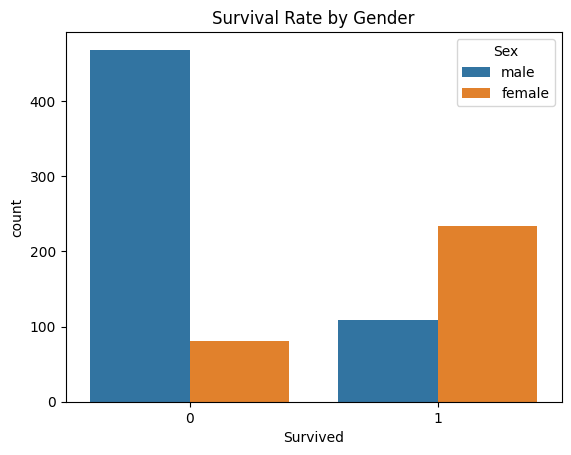

In [22]:
# Exploratory Data Analysis (EDA)
# Visualizing survival rate by gender
sns.countplot(x='Survived', hue='Sex', data=train)
plt.title('Survival Rate by Gender')
plt.show()

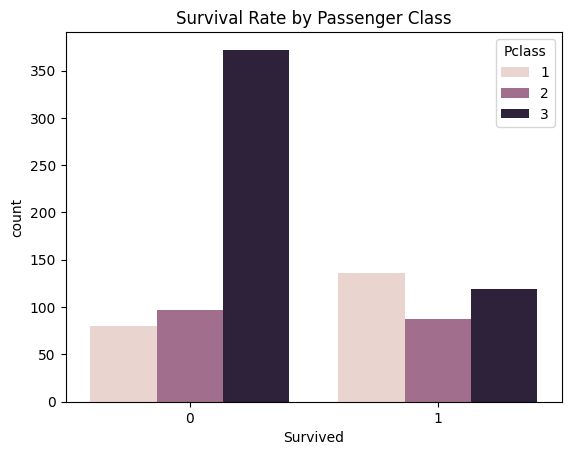

In [23]:
# Survival rate by Pclass
sns.countplot(x='Survived', hue='Pclass', data=train)
plt.title('Survival Rate by Passenger Class')
plt.show()

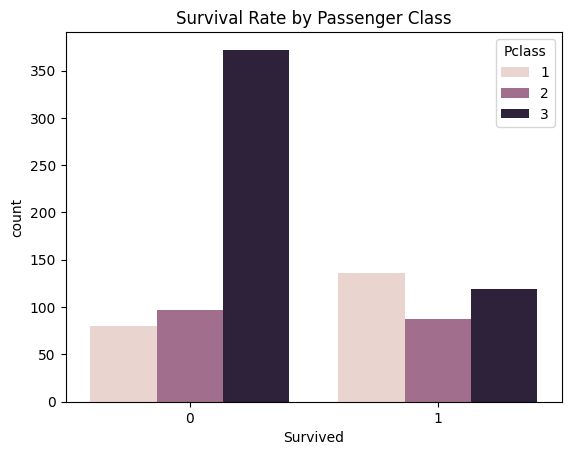

In [24]:
# Survival rate by Pclass
sns.countplot(x='Survived', hue='Pclass', data=train)
plt.title('Survival Rate by Passenger Class')
plt.show()

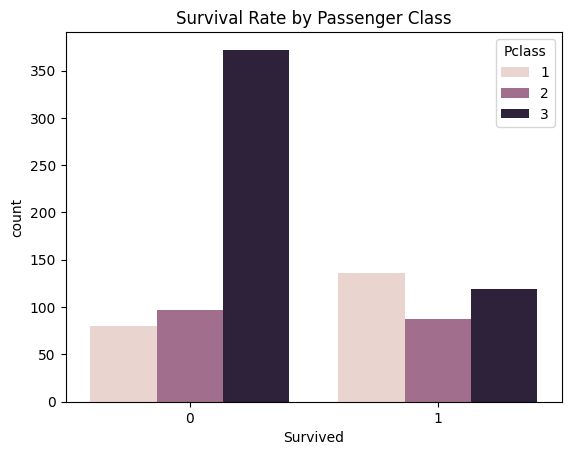

In [25]:
# Survival rate by Pclass
sns.countplot(x='Survived', hue='Pclass', data=train)
plt.title('Survival Rate by Passenger Class')
plt.show()

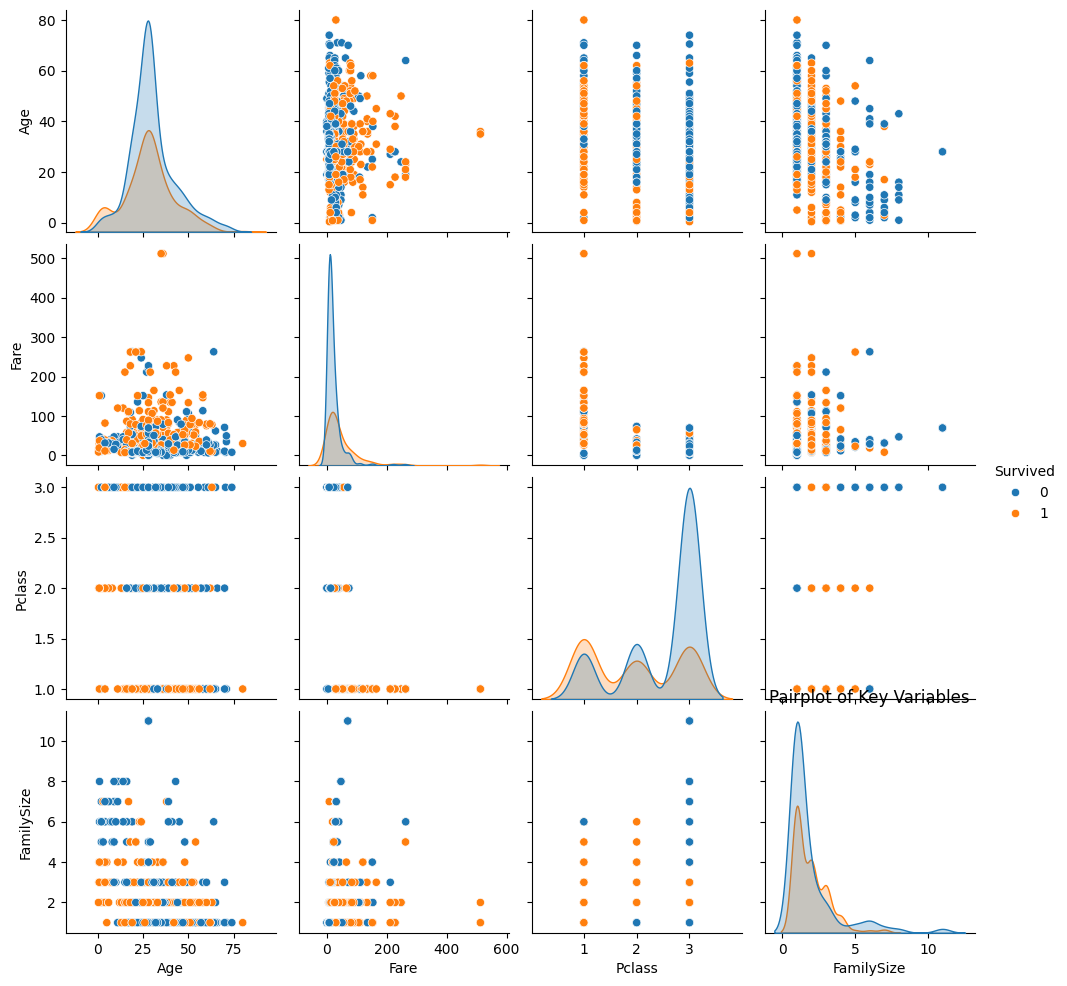

In [26]:
# Pairplot for key variables
sns.pairplot(train, hue='Survived', vars=['Age', 'Fare', 'Pclass', 'FamilySize'])
plt.title('Pairplot of Key Variables')
plt.show()

In [27]:
# Saving cleaned datasets for potential model training
train.to_csv('cleaned_train.csv', index=False)
test.to_csv('cleaned_test.csv', index=False)